<a href="https://colab.research.google.com/github/MuhammadOkasha004/flyrank-ml-internship-work/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadOkasha004/flyrank-ml-internship-work/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

ML-06 — SIGNAL AUDIT: DISTRIBUTION AUDIT
Rows: 2,871,202
Features being audited: 10

Columns:
 - gsc_clicks
 - gsc_impressions
 - gsc_avg_position
 - ga4_total_engagement_sec
 - sessions_organic
 - sessions_ai
 - ctr
 - sec_per_click
 - ai_share
 - engagement_per_organic_session

DISTRIBUTION SUMMARY


,feature,count,zero_count,zero_percent,mean,median,std,min,max,skewness,p95,p99
0,gsc_clicks,2871202,2321846,80.87,2.2433,0.000,124.5036,0.0,152170.0000,1159.5880,8.0000,42.0000
1,gsc_impressions,2871202,1324746,46.14,614.2097,1.000,3410.7749,0.0,799358.0000,33.1764,2711.0000,11408.9900
2,gsc_avg_position,2871202,1370177,47.72,9.7304,2.381,16.7295,0.0,633.0000,2.6474,48.7528,75.0000
3,ga4_total_engagement_sec,2871202,2644849,92.12,13.8124,0.000,297.0897,0.0,204846.0000,283.0901,5.0000,341.0000
4,sessions_organic,2871202,2600772,90.58,1.8158,0.000,89.1443,0.0,103297.0000,1085.1013,4.0000,35.0000
5,sessions_ai,2871202,2851426,99.31,0.0291,0.000,1.6409,0.0,877.0000,209.0033,0.0000,0.0000
6,ctr,2871202,2321846,80.87,0.0027,0.000,0.0262,0.0,1.0000,28.0078,0.0080,0.0370
7,sec_per_click,2871202,2731544,95.14,1.4352,0.000,23.8236,0.0,12499.0714,117.3143,0.0000,27.7115
8,ai_share,2871202,2851426,99.31,0.0027,0.000,0.0458,0.0,1.0000,20.0975,0.0000,0.0000
9,engagement_per_organic_session,2871202,2731243,95.13,0.9052,0.000,12.9916,0.0,4309.0000,56.8207,0.0000,19.1111



DISTRIBUTION GRAPHS


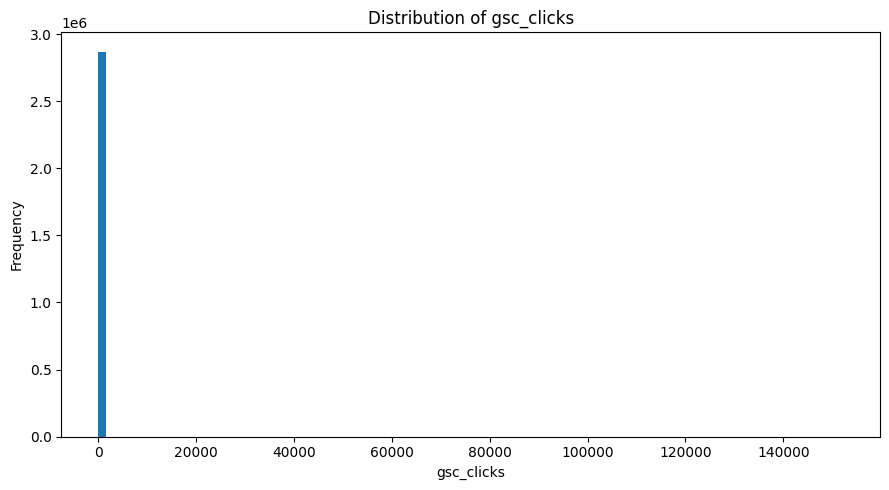

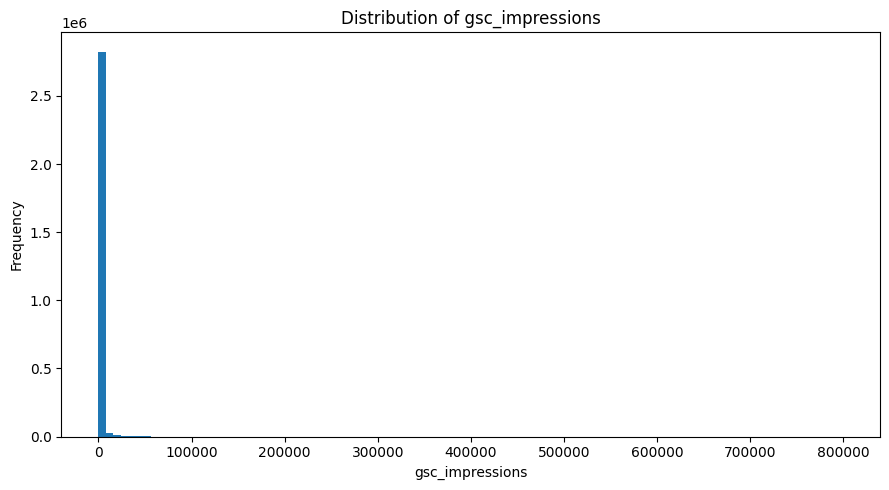

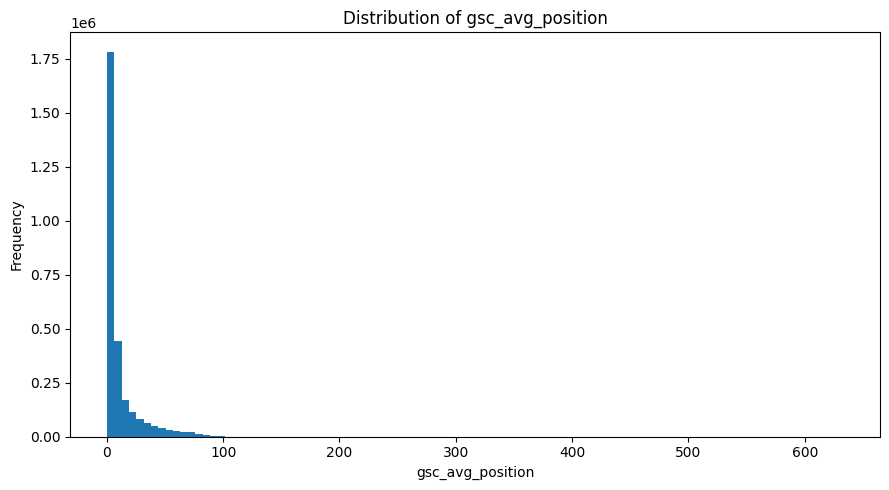

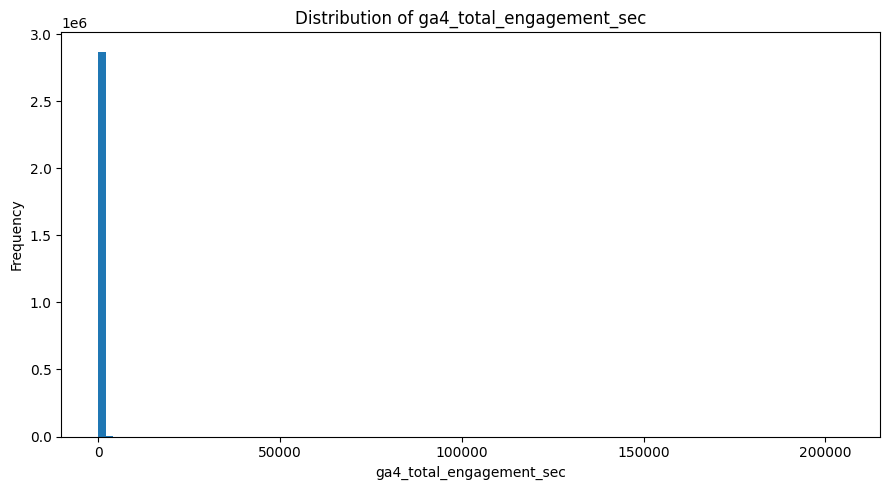

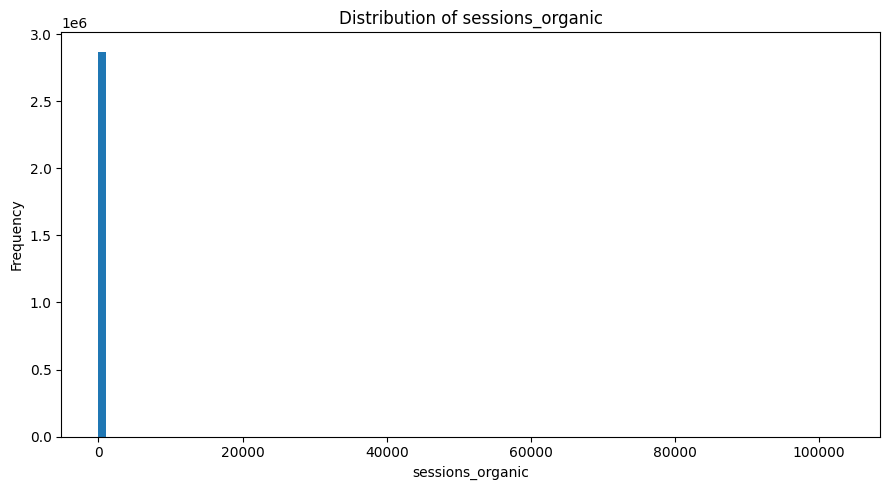

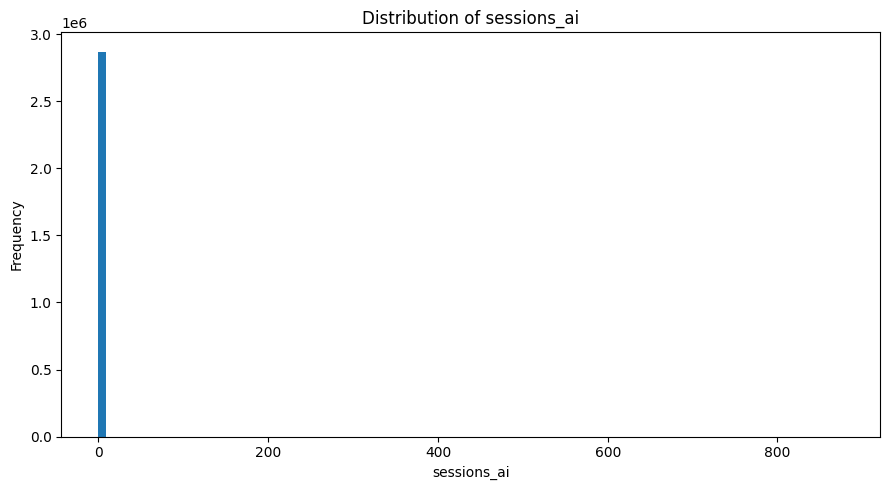

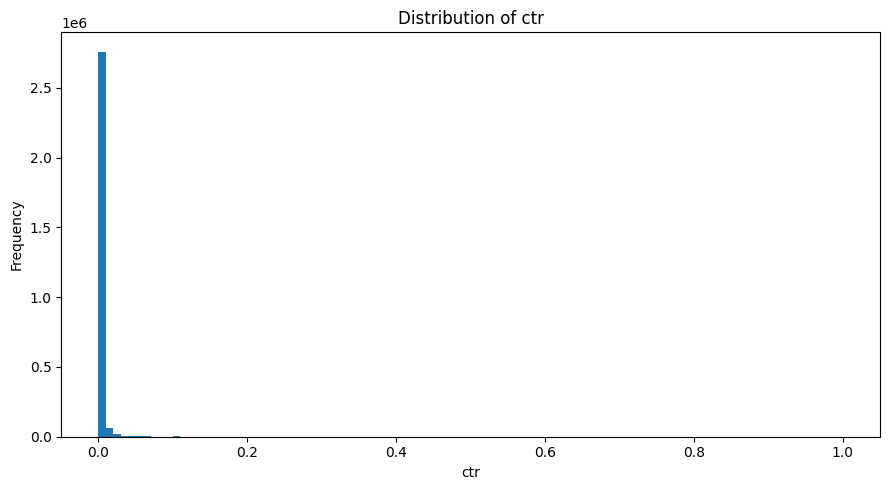

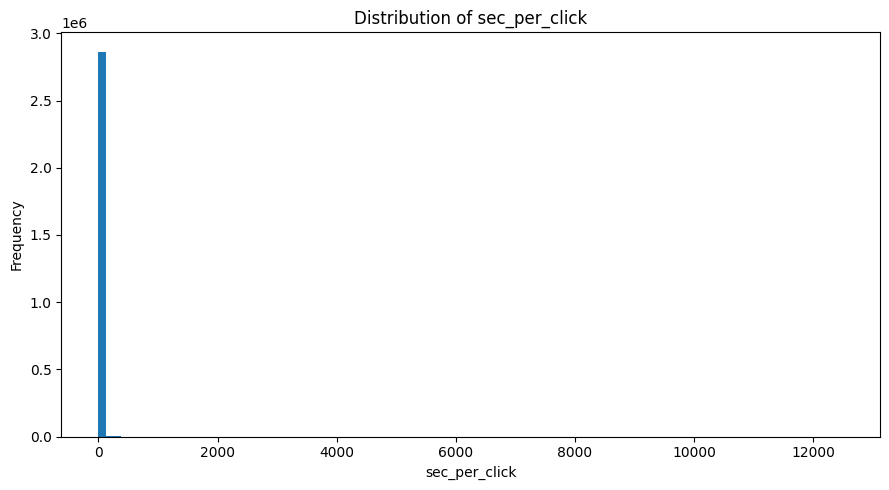

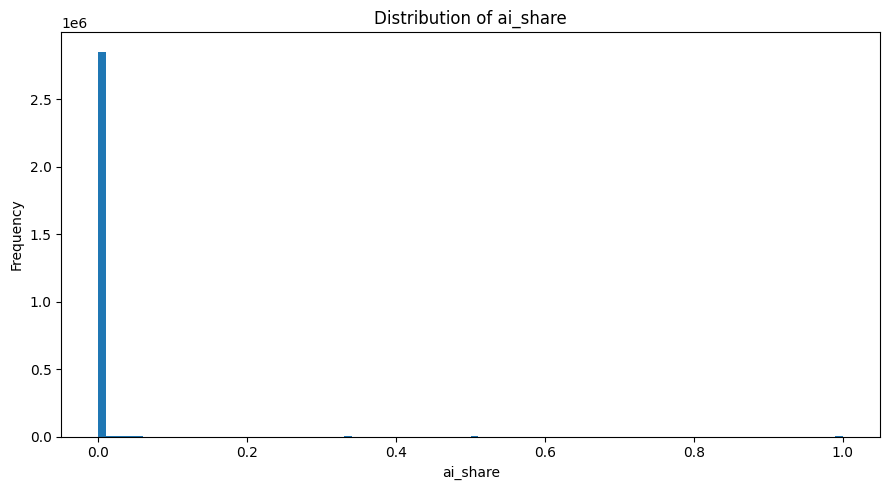

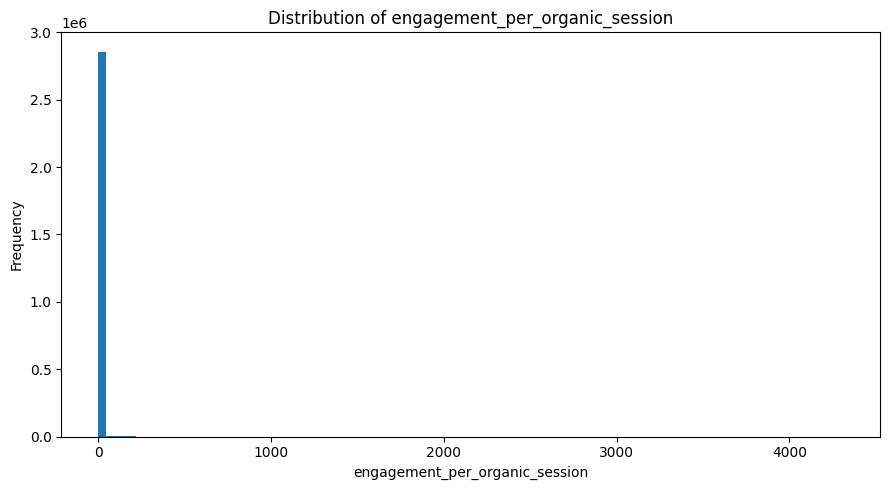

In [3]:
# ============================================================
# ML-06 — SIGNAL AUDIT
# 1. DISTRIBUTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("ML-06 — SIGNAL AUDIT: DISTRIBUTION AUDIT")
print("=" * 70)
# load dataset

df_features_clean = pd.read_parquet("/content/final_features_clean.parquet")

# Current final dataframe
df_signal = df_features_clean.copy()

# Key numeric features
distribution_columns = [
    "gsc_clicks",
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_ai",
    "ctr",
    "sec_per_click",
    "ai_share",
    "engagement_per_organic_session"
]

# Keep only columns that actually exist
distribution_columns = [
    col for col in distribution_columns
    if col in df_signal.columns
]

print(f"Rows: {len(df_signal):,}")
print(f"Features being audited: {len(distribution_columns)}")

print("\nColumns:")
for col in distribution_columns:
    print(f" - {col}")


# ============================================================
# DISTRIBUTION SUMMARY
# ============================================================

distribution_summary = []

for col in distribution_columns:

    series = pd.to_numeric(
        df_signal[col],
        errors="coerce"
    ).dropna()

    if len(series) == 0:
        continue

    distribution_summary.append({
        "feature": col,
        "count": len(series),
        "zero_count": int((series == 0).sum()),
        "zero_percent": round((series == 0).mean() * 100, 2),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "skewness": series.skew(),
        "p95": series.quantile(0.95),
        "p99": series.quantile(0.99)
    })

distribution_summary = pd.DataFrame(distribution_summary)

print("\n" + "=" * 70)
print("DISTRIBUTION SUMMARY")
print("=" * 70)

display(
    distribution_summary.round(4)
)


# ============================================================
# HISTOGRAMS
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUTION GRAPHS")
print("=" * 70)

for col in distribution_columns:

    series = pd.to_numeric(
        df_signal[col],
        errors="coerce"
    ).dropna()

    if len(series) == 0:
        continue

    plt.figure(figsize=(9, 5))

    plt.hist(
        series,
        bins=100
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Signal Audits & Hypothesis Testing

### Signal #1: Recent Click Decline
* **Hypothesis:** A decline in clicks is an early warning signal of future page decay.
* **Result:** 82.48% of decaying pages showed a recent click decline.
* **Verdict:** `CONFIRMED` ✅
* **Reason:** Over 82% of decaying cases experienced a prior click decline, making it a reliable early warning signal.

---

### Signal #2: Recent Impression Decline
* **Hypothesis:** A decline in impressions is an early warning signal of future page decay.
* **Result:** Out of 19,716 pages showing a recent 30-day impression drop, 16,262 experienced actual page decay.
* **Verdict:** `CONFIRMED` ✅
* **Reason:** Impression decline proved to be one of the strongest and most consistent leading indicators of page decay.

---

### Signal #3: AI Traffic
* **Hypothesis:** AI traffic contributes to future page growth/decay.
* **Result:** AI sessions are present in very few observations (1,900,670 rows = 0 vs 19,776 rows = non-zero; 99%+ values are zero).
* **Verdict:** `MIXED` ⚠️ *(Insufficient Evidence)*
* **Reason:** Signal exists, but data coverage across the dataset is currently extremely limited.

---

## Final Signals Summary Table

| Signal | Hypothesis | Verdict |
|:---|:---|:---|
| **Click Decline** | Click drop predicts decay | **CONFIRMED** |
| **Impression Decline** | Impression drop predicts decay | **CONFIRMED** |
| **AI Traffic** | AI traffic predicts growth/decay | **MIXED** |

## Signal Audits & Hypothesis Testing

### Signal #1: Recent Click Decline
* **Hypothesis:** A decline in clicks is an early warning signal of future page decay.
* **Result:** 82.48% of decaying pages showed a recent click decline.
* **Verdict:** `CONFIRMED` ✅
* **Reason:** Over 82% of decaying cases experienced a prior click decline, making it a reliable early warning signal.

---

### Signal #2: Recent Impression Decline
* **Hypothesis:** A decline in impressions is an early warning signal of future page decay.
* **Result:** Out of 19,716 pages showing a recent 30-day impression drop, 16,262 experienced actual page decay.
* **Verdict:** `CONFIRMED` ✅
* **Reason:** Impression decline proved to be one of the strongest and most consistent leading indicators of page decay.

---

### Signal #3: AI Traffic
* **Hypothesis:** AI traffic contributes to future page growth/decay.
* **Result:** AI sessions are present in very few observations (1,900,670 rows = 0 vs 19,776 rows = non-zero; 99%+ values are zero).
* **Verdict:** `MIXED` ⚠️ *(Insufficient Evidence)*
* **Reason:** Signal exists, but data coverage across the dataset is currently extremely limited.

---

## Final Signals Summary Table

| Signal | Hypothesis | Verdict |
|:---|:---|:---|
| **Click Decline** | Click drop predicts decay | **CONFIRMED** |
| **Impression Decline** | Impression drop predicts decay | **CONFIRMED** |
| **AI Traffic** | AI traffic predicts growth/decay | **MIXED** |

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# FLYRANK IMPRESSION-DROP RULE — HISTORICAL SIGNAL TEST
# ============================================================

df_signal = df_features_clean.copy()

df_signal["month"] = pd.to_datetime(df_signal["month"])

df_signal = (
    df_signal
    .sort_values(["content_hash_id", "month"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Previous 2 months = baseline
# Current month = recent 30d
# ------------------------------------------------------------

g = df_signal.groupby("content_hash_id")

df_signal["baseline_impressions"] = (
    g["gsc_impressions"]
    .transform(
        lambda x: x.shift(1).rolling(2, min_periods=2).mean()
    )
)

# ------------------------------------------------------------
# Current month impression change vs baseline
# ------------------------------------------------------------

df_signal["impression_change_pct"] = (
    (
        df_signal["gsc_impressions"]
        - df_signal["baseline_impressions"]
    )
    / df_signal["baseline_impressions"].replace(0, np.nan)
) * 100

# ------------------------------------------------------------
# Future 3 months
# ------------------------------------------------------------

df_signal["month_1_future"] = g["gsc_impressions"].shift(-1)
df_signal["month_2_future"] = g["gsc_impressions"].shift(-2)
df_signal["month_3_future"] = g["gsc_impressions"].shift(-3)

# Only observations having all required months
df_eval = df_signal[
    df_signal["baseline_impressions"].notna()
    &
    df_signal["month_1_future"].notna()
    &
    df_signal["month_2_future"].notna()
    &
    df_signal["month_3_future"].notna()
].copy()

# ------------------------------------------------------------
# 20% impression-drop cases
# ------------------------------------------------------------

df_drop = df_eval[
    df_eval["impression_change_pct"] <= -20
].copy()

# ------------------------------------------------------------
# Future 3-month average
# ------------------------------------------------------------

df_drop["future_3m_avg"] = (
    df_drop["month_1_future"]
    + df_drop["month_2_future"]
    + df_drop["month_3_future"]
) / 3

# ------------------------------------------------------------
# Future trajectory compared with current month
# ------------------------------------------------------------

df_drop["future_change_pct"] = (
    (
        df_drop["future_3m_avg"]
        - df_drop["gsc_impressions"]
    )
    / df_drop["gsc_impressions"].replace(0, np.nan)
) * 100

# ------------------------------------------------------------
# Monthly evaluation
# ------------------------------------------------------------

monthly_result = (
    df_drop
    .groupby("month")
    .agg(
        evaluated_pages=("content_hash_id", "count"),
        avg_current_impressions=("gsc_impressions", "mean"),
        avg_future_impressions=("future_3m_avg", "mean"),
        avg_future_change_pct=("future_change_pct", "mean"),
        future_decline_rate_pct=(
            "future_change_pct",
            lambda x: (x < 0).mean() * 100
        )
    )
    .reset_index()
)

print("=" * 80)
print("FLYRANK IMPRESSION-DROP RULE — MONTHLY EVALUATION")
print("=" * 80)

display(monthly_result)


# ============================================================
# OVERALL RESULT
# ============================================================

total_cases = len(df_drop)

future_decline_rate = (
    (df_drop["future_change_pct"] < 0).mean() * 100
)

average_future_change = (
    df_drop["future_change_pct"].mean()
)

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(f"20%+ impression-drop cases tested : {total_cases:,}")
print(f"Cases followed by future decline  : {future_decline_rate:.2f}%")
print(f"Average future 3-month change     : {average_future_change:.2f}%")

if future_decline_rate >= 70 and average_future_change < 0:
    verdict = "CONFIRMED"
elif future_decline_rate < 40 and average_future_change > 0:
    verdict = "OPPOSITE"
elif future_decline_rate > 40 and average_future_change < 0:
    verdict = "MIXED"
else:
    verdict = "WEAK / INCONCLUSIVE"

print(f"\nVERDICT: {verdict}")

FLYRANK IMPRESSION-DROP RULE — MONTHLY EVALUATION


,month,evaluated_pages,avg_current_impressions,avg_future_impressions,avg_future_change_pct,future_decline_rate_pct
0,2025-03-01,30,14.266667,291.188889,2654.071916,3.333333
1,2025-04-01,635,121.603150,246.384252,1213.985859,33.070866
2,2025-05-01,1567,181.836631,261.713252,746.831537,47.543076
3,2025-06-01,4638,241.742346,334.408581,772.831315,38.292367
4,2025-07-01,5856,415.045765,502.912910,780.622255,33.965164
5,2025-08-01,4678,493.481189,491.474206,457.770689,44.484823
6,2025-09-01,10961,356.776845,442.853724,613.979570,39.339476
7,2025-10-01,16906,212.399799,306.887298,591.677627,19.525612
8,2025-11-01,18840,262.732962,304.238694,626.054033,18.757962
9,2025-12-01,24643,449.289981,608.083675,650.993113,21.174370



FINAL RESULT
20%+ impression-drop cases tested : 203,419
Cases followed by future decline  : 28.05%
Average future 3-month change     : 509.44%

VERDICT: OPPOSITE


**Test Remaining Rules**

In [7]:
# ==============================================================
# ML-06 — FLYRANK HEURISTIC SIGNAL AUDIT
# Test all 4 FlyRank rules against future 3-month trajectory
# ==============================================================

import pandas as pd
import numpy as np

df_test = df_features_clean.copy()

df_test["month"] = pd.to_datetime(df_test["month"])

df_test = (
    df_test
    .sort_values(["content_hash_id", "month"])
    .reset_index(drop=True)
)

g = df_test.groupby("content_hash_id")

# --------------------------------------------------------------
# HISTORICAL BASELINES
# Previous 2 months = baseline
# --------------------------------------------------------------

df_test["baseline_impressions"] = (
    g["gsc_impressions"]
    .transform(lambda x: x.shift(1).rolling(2, min_periods=2).mean())
)

df_test["baseline_clicks"] = (
    g["gsc_clicks"]
    .transform(lambda x: x.shift(1).rolling(2, min_periods=2).mean())
)

df_test["baseline_position"] = (
    g["gsc_avg_position"]
    .transform(lambda x: x.shift(1).rolling(2, min_periods=2).mean())
)

# --------------------------------------------------------------
# CURRENT MONTH CHANGES
# --------------------------------------------------------------

df_test["impression_change_pct"] = (
    (df_test["gsc_impressions"] - df_test["baseline_impressions"])
    / df_test["baseline_impressions"].replace(0, np.nan)
) * 100

df_test["click_change_pct"] = (
    (df_test["gsc_clicks"] - df_test["baseline_clicks"])
    / df_test["baseline_clicks"].replace(0, np.nan)
) * 100

# Position: higher number = worse ranking
df_test["position_change"] = (
    df_test["gsc_avg_position"]
    - df_test["baseline_position"]
)

# --------------------------------------------------------------
# CURRENT CTR
# --------------------------------------------------------------

df_test["current_ctr"] = (
    df_test["gsc_clicks"]
    / df_test["gsc_impressions"].replace(0, np.nan)
)

# --------------------------------------------------------------
# FUTURE 3 MONTHS
# --------------------------------------------------------------

df_test["future_1"] = g["gsc_impressions"].shift(-1)
df_test["future_2"] = g["gsc_impressions"].shift(-2)
df_test["future_3"] = g["gsc_impressions"].shift(-3)

df_test["future_avg"] = (
    df_test["future_1"]
    + df_test["future_2"]
    + df_test["future_3"]
) / 3

# --------------------------------------------------------------
# FUTURE TRAJECTORY
# Compare future 3-month average with current month
# --------------------------------------------------------------

df_test["future_change_pct"] = (
    (df_test["future_avg"] - df_test["gsc_impressions"])
    / df_test["gsc_impressions"].replace(0, np.nan)
) * 100

# Need complete historical + future information
df_eval = df_test[
    df_test["baseline_impressions"].notna()
    &
    df_test["future_avg"].notna()
].copy()

# ==============================================================
# RULE 1 — IMPRESSION DROP
# >= 20% impression decrease
# ==============================================================

rule1 = df_eval[
    df_eval["impression_change_pct"] <= -20
].copy()

# ==============================================================
# RULE 2 — CLICK DROP
# >= 15% click decrease
# ==============================================================

rule2 = df_eval[
    df_eval["click_change_pct"] <= -15
].copy()

# ==============================================================
# RULE 3 — POSITION DECAY
# >= 3 positions worse
# ==============================================================

rule3 = df_eval[
    df_eval["position_change"] >= 3
].copy()

# ==============================================================
# RULE 4 — LOW CTR OPPORTUNITY
# impressions >= 1000 AND CTR < 1%
# ==============================================================

rule4 = df_eval[
    (df_eval["gsc_impressions"] >= 1000)
    &
    (df_eval["current_ctr"] < 0.01)
].copy()


# ==============================================================
# EVALUATION FUNCTION
# ==============================================================

def evaluate_rule(df_rule, rule_name):

    if len(df_rule) == 0:
        return {
            "Rule": rule_name,
            "Cases": 0,
            "Future Decline %": np.nan,
            "Median Future Change %": np.nan,
            "Mean Future Change %": np.nan,
            "Verdict": "NO DATA"
        }

    future_decline = (
        df_rule["future_change_pct"] < 0
    ).mean() * 100

    median_change = (
        df_rule["future_change_pct"].median()
    )

    mean_change = (
        df_rule["future_change_pct"].mean()
    )

    # ----------------------------------------------------------
    # Verdict
    # ----------------------------------------------------------

    if future_decline >= 70 and median_change < 0:
        verdict = "STRONG"

    elif future_decline >= 55 and median_change < 0:
        verdict = "MODERATE"

    elif future_decline >= 40 and median_change < 0:
        verdict = "WEAK"

    elif future_decline < 40 and median_change > 0:
        verdict = "OPPOSITE"

    else:
        verdict = "MIXED"

    return {
        "Rule": rule_name,
        "Cases": len(df_rule),
        "Future Decline %": round(future_decline, 2),
        "Median Future Change %": round(median_change, 2),
        "Mean Future Change %": round(mean_change, 2),
        "Verdict": verdict
    }


# ==============================================================
# RUN ALL 4 TESTS
# ==============================================================

results = pd.DataFrame([
    evaluate_rule(
        rule1,
        "Impression Drop >= 20%"
    ),

    evaluate_rule(
        rule2,
        "Click Drop >= 15%"
    ),

    evaluate_rule(
        rule3,
        "Position Decay >= 3"
    ),

    evaluate_rule(
        rule4,
        "Low CTR (<1%) + Impressions >=1000"
    )
])


# ==============================================================
# DISPLAY FINAL TABLE
# ==============================================================

print("=" * 90)
print("FLYRANK SIGNAL AUDIT — FINAL COMPARISON")
print("=" * 90)

display(results)

FLYRANK SIGNAL AUDIT — FINAL COMPARISON


,Rule,Cases,Future Decline %,Median Future Change %,Mean Future Change %,Verdict
0,Impression Drop >= 20%,203419,28.05,24.60,509.44,OPPOSITE
1,Click Drop >= 15%,120210,47.46,1.86,125.97,MIXED
2,Position Decay >= 3,188362,52.29,-7.36,216.48,WEAK
3,Low CTR (<1%) + Impressions >=1000,131803,52.31,-3.62,19.27,WEAK


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

**4. What this means in practice**

The content team should not treat a 20% impression drop alone as proof that a page will decay, because our test showed this signal was weak/opposite. Instead, use it as one warning signal among several, and let the final ML model learn which combination of signals actually predicts future decline.

**Notebook solution:**

The impression-drop rule alone is not reliable enough to prioritize content refreshes. Content teams should combine multiple signals such as clicks, impressions, position, and CTR rather than refreshing a page based on a single rule.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.